# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [ ]:
ROLL_NO = 1024170415          #
NAME = "vijaykiran"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [ ]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [ ]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [ ]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170415   Name: vijaykiran   Fingerprint: AE86A0E5   Tickets: 12

Ticket_ID                                                                                Ticket_Text
      T01                                                      The Wi-Fi works, but the VPN doesn't.
      T02                                                              The LMS says 'Not Submitted'.
      T03                 Laptop crashes while opening after the latest update. It worked yesterday.
      T04               I tried restarting the Python while uploading the file. It worked yesterday.
      T05                                               Call me on +91 98765 43210 or 0175-239-3201.
      T06                                                             Error code 0x80070005 appears.
      T07                                             The MATLAB failed to open. Can you check this?
      T08                                          The Matlab stopped responding. Please resolve it.
      T09

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [ ]:
# Your code


from collections import Counter
import pandas as pd

processed = {
    row.Ticket_ID: process_ticket(row.Ticket_Text)
    for row in df.itertuples(index=False)
}

rows = []
for ticket_id, result in processed.items():
    rows.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique tokens": len(set(result["tokens"])),
        "Final tokens": len(result["final"])
    })

q1_table = pd.DataFrame(rows)

total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation": q1_table["Punctuation"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique tokens": "-",
    "Final tokens": q1_table["Final tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)
display(q1_table)

selected_id = FOCUS[0]
selected = processed[selected_id]

print("Selected ticket:", selected_id)
print("Original text:",
      df.loc[df["Ticket_ID"] == selected_id, "Ticket_Text"].iloc[0])
print("Sentences:", selected["sentences"])
print("Tokens:", selected["tokens"])
print("Punctuation tokens:", selected["punct"])
print("Stopwords:", selected["stops"])
print("Final tokens:", selected["final"])


,Ticket_ID,Sentences,Tokens,Punctuation,Stopwords,Unique tokens,Final tokens
0,T01,1,10,2,4,9,4
1,T02,1,7,2,1,7,4
2,T03,2,13,2,4,12,7
3,T04,2,14,2,5,12,7
4,T05,1,9,1,3,9,5
5,T06,1,5,1,0,5,4
6,T07,2,11,2,5,11,4
7,T08,2,9,2,2,8,5
8,T09,2,12,2,4,11,6
9,T10,2,11,2,3,11,6


Selected ticket: T05
Original text: Call me on +91 98765 43210 or 0175-239-3201.
Sentences: ['Call me on +91 98765 43210 or 0175-239-3201.']
Tokens: ['call', 'me', 'on', '+91', '98765', '43210', 'or', '0175-239-3201', '.']
Punctuation tokens: ['.']
Stopwords: ['me', 'on', 'or']
Final tokens: ['call', '+91', '98765', '43210', '0175-239-3201']


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [ ]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Your code

import re

raw_tickets = df["Ticket_Text"].tolist()

# Patterns for extraction
long_word_pattern = r"\b[A-Za-z]{6,}\b"
number_pattern = r"\b\d+(?:\.\d+)*\b"
capitalized_pattern = r"\b[A-Z][a-zA-Z]*\b"
vowel_pattern = r"\b[AEIOUaeiou][A-Za-z]*\b"

def extract_all(lines):
    return {
        "Words longer than 5 letters":
            [x for line in lines for x in re.findall(long_word_pattern, line)],
        "Numbers":
            [x for line in lines for x in re.findall(number_pattern, line)],
        "Capitalized words":
            [x for line in lines for x in re.findall(capitalized_pattern, line)],
        "Words starting with a vowel":
            [x for line in lines for x in re.findall(vowel_pattern, line)]
    }

for category, matches in extract_all(raw_tickets).items():
    print(f"\n{category} ({len(matches)} matches):")
    print(matches)

# Replacement patterns
email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
url_pattern = r"(?:https?://|www\.)[^\s]+"
phone_pattern = (
    r"(?<!\w)(?:\+\d{1,3}[ -]\d{5}[ -]\d{5}"
    r"|\d{5}[ -]\d{5}"
    r"|\d{4}[- ]\d{3,5}[- ]\d{4,5})(?!\w)"
)

def redact_text(text):
    text = re.sub(email_pattern, "<EMAIL>", text)
    text = re.sub(url_pattern, "<URL>", text)
    text = re.sub(phone_pattern, "<PHONE>", text)
    return text

print("\nREDACTED TICKETS")
for line in TEST_LINES:
    print(redact_text(line))

print("\nREDACTED DATASET")
for line in raw_tickets:
    print(redact_text(line))

# Estimate sentence-initial capitalized words
sentence_initials = []
for line in raw_tickets:
    for match in re.finditer(r"(?<!\w)[A-Z][a-zA-Z]*", line):
        prefix = line[:match.start()]
        if not prefix.strip() or re.search(r"[.!?]\s*$", prefix):
            sentence_initials.append(match.group())

capitalized = extract_all(raw_tickets)["Capitalized words"]
print("\nTotal capitalized matches:", len(capitalized))
print("Sentence-initial capitalized matches:", len(sentence_initials))
print("Sentence-initial share:",
      round(100 * len(sentence_initials) / max(len(capitalized), 1), 2), "%")



Words longer than 5 letters (38 matches):
['Submitted', 'Laptop', 'crashes', 'opening', 'latest', 'update', 'worked', 'yesterday', 'restarting', 'Python', 'uploading', 'worked', 'yesterday', 'appears', 'MATLAB', 'failed', 'Matlab', 'stopped', 'responding', 'Please', 'resolve', 'working', 'yesterday', 'another', 'computer', 'projector', 'stopped', 'responding', 'several', 'locked', 'uploading', 'several', 'unable', 'student', 'portal', 'uploading', 'another', 'solution']

Numbers (6 matches):
['91', '98765', '43210', '0175', '239', '3201']

Capitalized words (30 matches):
['The', 'Wi', 'Fi', 'VPN', 'The', 'LMS', 'Not', 'Submitted', 'Laptop', 'It', 'I', 'Python', 'It', 'Call', 'Error', 'The', 'MATLAB', 'Can', 'The', 'Matlab', 'Please', 'The', 'It', 'The', 'I', 'I', 'VPN', 'I', 'I', 'Is']

Words starting with a vowel (30 matches):
['opening', 'after', 'update', 'It', 'I', 'uploading', 'It', 'on', 'or', 'Error', 'appears', 'open', 'it', 'e', 'It', 'on', 'another', 'I', 'I', 'out', 'of', '

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [ ]:
# Your code

from nltk.tokenize import RegexpTokenizer, word_tokenize

token_pattern = (
    r"https?://[^\s]+|www\.[^\s]+"
    r"|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}"
    r"|\+?\d{1,3}[ -]\d{5}[ -]\d{5}"
    r"|\d{4}[- ]\d{3,5}[- ]\d{4,5}"
    r"|\d+(?:\.\d+)+%?"
    r"|[A-Za-z]+(?:['’][A-Za-z]+)+"
    r"|[A-Za-z]+(?:-[A-Za-z]+)+"
    r"|\d+%?"
    r"|[A-Za-z]+"
    r"|[^\w\s]"
)

tokenizer = RegexpTokenizer(token_pattern)

def my_tokenize(text):
    return tokenizer.tokenize(text)

print("TEST_LINES COMPARISON")
for line in TEST_LINES:
    print("\nText:", line)
    print("Custom:", my_tokenize(line))
    print("NLTK:  ", word_tokenize(line))

print("\nTICKET COMPARISON")
different_tickets = []

for row in df.itertuples(index=False):
    custom = my_tokenize(row.Ticket_Text)
    nltk_tokens = word_tokenize(row.Ticket_Text)

    if custom != nltk_tokens:
        different_tickets.append(row.Ticket_ID)
        print("\n", row.Ticket_ID)
        print("Custom:", custom)
        print("NLTK:", nltk_tokens)

print("\nTickets tokenized differently:",
      len(different_tickets), "out of", len(df))
print("Different ticket IDs:", different_tickets)


TEST_LINES COMPARISON

Text: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Custom: ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']
NLTK:   ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

Text: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
Custom: ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5%', 'done', ';', 'fee', 'Rs', '1', ',', '250', '.']
NLTK:   ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

Text: The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
Custom: ['Th

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [ ]:

from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from collections import Counter

unique_final = sorted({
    token
    for result in processed.values()
    for token in result["final"]
})

porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

# Select a suffix using the dataset's actual words
suffix_candidates = ["ing", "ed", "ly", "es", "s"]
suffix_counts = {
    suffix: sum(word.endswith(suffix) for word in unique_final)
    for suffix in suffix_candidates
}

valid_suffixes = [
    suffix for suffix in suffix_candidates
    if suffix_counts[suffix] >= 2
]

chosen_suffix = max(
    valid_suffixes,
    key=lambda suffix: suffix_counts[suffix]
) if valid_suffixes else "ing"

regexp_stemmer = RegexpStemmer(regexp=chosen_suffix + r"$")

# POS tags from actual ticket sequences
word_pos = {}
for result in processed.values():
    tagged = pos_tag(result["final"])
    for word, tag in tagged:
        word_pos.setdefault(word, tag)

def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

stem_rows = []

for word in unique_final:
    tag = word_pos.get(word, "NN")
    wn_pos = get_wordnet_pos(tag)

    values = {
        "Word": word,
        "POS": tag,
        "Porter": porter.stem(word),
        "Lancaster": lancaster.stem(word),
        "Regexp": regexp_stemmer.stem(word),
        "Lemma": lemmatizer.lemmatize(word, pos=wn_pos)
    }
    stem_rows.append(values)

stem_table = pd.DataFrame(stem_rows)

# Show only words where at least two methods differ
method_columns = ["Porter", "Lancaster", "Regexp", "Lemma"]
different_rows = stem_table[
    stem_table[method_columns].nunique(axis=1) > 1
]

print("Chosen RegexpStemmer suffix:", repr(chosen_suffix))
print("Words ending in this suffix:", [
    word for word in unique_final if word.endswith(chosen_suffix)
])
print("\nWords where stemming/lemmatization outputs differ:")
display(different_rows.reset_index(drop=True))

print("\nNumber of unique final tokens:", len(unique_final))
print("Number of rows with differing outputs:", len(different_rows))


Chosen RegexpStemmer suffix: 'ed'
Words ending in this suffix: ['failed', 'locked', 'stopped', 'submitted', 'tried', 'worked']

Words where stemming/lemmatization outputs differ:


,Word,POS,Porter,Lancaster,Regexp,Lemma
0,another,DT,anoth,anoth,another,another
1,appears,VBZ,appear,appear,appears,appear
2,call,NN,call,cal,call,call
3,code,NN,code,cod,code,code
4,computer,NN,comput,comput,computer,computer
5,crashes,NNS,crash,crash,crashes,crash
6,error,NN,error,er,error,error
7,file,NN,file,fil,file,file
8,latest,JJS,latest,latest,latest,late
9,lms,NNS,lm,lms,lms,lm



Number of unique final tokens: 50
Number of rows with differing outputs: 33


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

,Corpus,Total tokens,Unique tokens,TTR
0,S1 (all tokens),137,76,0.5547
1,S2 (no punctuation),115,71,0.6174
2,S3 (final tokens),67,50,0.7463
3,S4 (S3 + Porter),67,47,0.7015



Top 10 words of S1:
[('.', 16), ('the', 14), ('i', 5), ('while', 4), ('it', 4), ('yesterday', 3), ('tried', 3), ('uploading', 3), ('file', 3), ('works', 2)]

Top 10 words of S3:
[('yesterday', 3), ('tried', 3), ('uploading', 3), ('file', 3), ('works', 2), ('vpn', 2), ('worked', 2), ('matlab', 2), ('stopped', 2), ('responding', 2)]


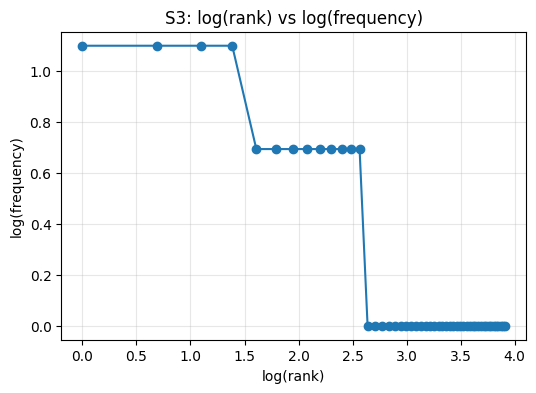

Top 5 bigrams of S1:
  ('.', 'it'): 3
  ('yesterday', '.'): 3
  ('while', 'uploading'): 3
  ('uploading', 'the'): 3
  ('the', 'file'): 3

Top 5 bigrams of S3:
  ('uploading', 'file'): 3
  ('worked', 'yesterday'): 2
  ('stopped', 'responding'): 2
  ('tried', 'several'): 2
  ('several', 'times'): 2


In [ ]:
# Your code
import numpy as np
import matplotlib.pyplot as plt
from nltk.util import bigrams as nltk_bigrams

S1 = [t for r in processed.values() for t in r["tokens"]]
S2 = [t for r in processed.values() for t in r["tokens"] if not is_punct(t)]
S3 = [t for r in processed.values() for t in r["final"]]
S4 = [porter.stem(t) for t in S3]

def corpus_stats(name, toks):
    total, uniq = len(toks), len(set(toks))
    return {"Corpus": name, "Total tokens": total, "Unique tokens": uniq,
            "TTR": round(uniq / total, 4) if total else 0.0}

stats = pd.DataFrame([
    corpus_stats("S1 (all tokens)", S1),
    corpus_stats("S2 (no punctuation)", S2),
    corpus_stats("S3 (final tokens)", S3),
    corpus_stats("S4 (S3 + Porter)", S4),
])
display(stats)

print("\nTop 10 words of S1:")
print(Counter(S1).most_common(10))
print("\nTop 10 words of S3:")
print(Counter(S3).most_common(10))

# Zipf-style plot for S3
freqs = sorted(Counter(S3).values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)
plt.figure(figsize=(6, 4))
plt.plot(np.log(ranks), np.log(freqs), marker="o")
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("S3: log(rank) vs log(frequency)")
plt.grid(True, alpha=0.3)
plt.show()

# Bigrams are built inside each ticket so they do not cross ticket boundaries
def top_bigrams(sequences, n=5):
    c = Counter()
    for seq in sequences:
        c.update(nltk_bigrams(seq))
    return c.most_common(n)

print("Top 5 bigrams of S1:")
for bg, cnt in top_bigrams([r["tokens"] for r in processed.values()]):
    print(f"  {bg}: {cnt}")
print("\nTop 5 bigrams of S3:")
for bg, cnt in top_bigrams([r["final"] for r in processed.values()]):
    print(f"  {bg}: {cnt}")

In [ ]:

# (a) TTR comparison
print("TTR comparison:")
print(stats.to_string(index=False))

# (b) Tokenizer difference
print("\n(b) Example where tokenizers differ:")
for line in TEST_LINES:
    custom = my_tokenize(line)
    nltk_tokens = word_tokenize(line)

    if custom != nltk_tokens:
        print("Text:", line)
        print("Custom:", custom)
        print("NLTK:", nltk_tokens)
        break

# Use the correct DataFrame name from Q4
# stem_table contains Word, Porter, Lancaster, Regexp, and Lemma

# (c) Possible undesirable stemming
print("\n(c) Possible undesirable stemming:")
bad = stem_table[
    (stem_table["Lancaster"] != stem_table["Lemma"]) &
    (stem_table["Lancaster"].str.len()
     <= stem_table["Word"].str.len() - 2)
]

if not bad.empty:
    print(bad[["Word", "Porter", "Lancaster", "Lemma"]]
          .head(10).to_string(index=False))
else:
    print("No clear example found. Inspect the full stemming table:")
    print(stem_table.to_string(index=False))

# (d) POS-aware lemmatization vs stemming
print("\n(d) Lemmatization examples:")
good = stem_table[
    (stem_table["Lemma"] != stem_table["Porter"]) &
    (stem_table["Lemma"] != stem_table["Word"])
]

if not good.empty:
    print(good[["Word", "POS", "Porter", "Lemma"]]
          .head(10).to_string(index=False))
else:
    print("No example found with this filter. Inspect stem_table.")


TTR comparison:
             Corpus  Total tokens  Unique tokens    TTR
    S1 (all tokens)           137             76 0.5547
S2 (no punctuation)           115             71 0.6174
  S3 (final tokens)            67             50 0.7463
   S4 (S3 + Porter)            67             47 0.7015

(b) Example where tokenizers differ:
Text: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Custom: ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']
NLTK: ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

(c) Possible undesirable stemming:
     Word    Porter Lancaster     Lemma
  another     anoth     anoth   another
 computer    comput    comput  computer
    error     error        er     error
     open      open        op     

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*TTR increases from 0.5547 in S1 to 0.6174 in S2 because removing punctuation reduces the total number of tokens. It further increases to 0.7463 in S3 because stopwords are removed, leaving a higher proportion of unique words. Finally, TTR decreases to 0.7015 in S4 because Porter stemming converts related word forms into common stems, reducing the number of unique tokens.